# DS 3 - Channel Heterogeneity & Dynamics

**Research Question:** Does acquisition channel (Shopify DTC vs Lazada vs Shopee vs Social referral) produce statistically distinct 90-day retention rates, and if so, which channel produces the highest-LTV customers?

**Methodology:** Applying the Fader Customer-Base Audit (Heterogeneity & Dynamics Lenses) using BG/NBD and Gamma-Gamma probabilistic models, alongside period-over-period dynamics analysis.

## Executive Summary: Channel Performance & Customer Retention

**1. The "Leaky Bucket" Churn Crisis**
- **The Problem:** We do not have a functional customer loyalty pipeline. Across almost all channels, 80% to 97% of customers hit a "wall" and leave the brand by their second year.
- **The VIP Bleed:** Most alarmingly, we are losing more than half of our best, highest-spending customers year-over-year.
- *For detailed data, see: Customer Movement Analysis and Dynamics Analysis*

**2. DTC: The High-Volume, Low-Loyalty Engine**
- **The Role:** DTC is our total revenue engine, projected to bring in the most money ($159,045) over the next 12 months simply because of its massive size.
- **The Reality:** It operates purely on volume. Customers spend the least on their first purchase (around $62), and the channel survives solely by spending aggressively to acquire new users to replace the massive number who leave each year.
- *For detailed data, see: Future Value Projection and Profiling Analysis: AOV & AOF*

**3. Lazada: The Stalled Premium Channel**
- **The Role:** Historically, Lazada was our best channel. It brought in high-value customers who spent double our website average (around $138) and proved to be the most naturally loyal over a 90-day period.
- **The Reality:** The engine has completely stalled. New customer acquisition is virtually dead, and the historical user base is fading fast. With a median predicted future spend of just $4.38, the vast majority of our Lazada base is now inactive "dead weight".
- *For detailed data, see: Future Value Projection and Dynamics Analysis*

**4. Shopee: The High-Risk Wildcard**
- **The Role:** Shopee looks incredible on paper right now. It has the highest predicted individual customer value ($86) and the most "active" looking users.
- **The Reality:** It is a brand-new channel, and these numbers are still in the "honeymoon phase." Early data already shows that Shopee customers actually drop off faster and are less loyal than those from our DTC website.
- *For detailed data, see: Future Value Projection and Customer Activity Analysis*

**5. Channel Matters More Than Geography**
- **The Reality:** Data confirms that where a customer lives (Singapore vs. Malaysia) does not impact their loyalty. The platform they use to find us—the acquisition channel—is the true driver of their spending habits and retention.
- **Strategic Bottom Line:** The business is highly capable of driving first-time purchases, but we treat every channel as a one-time transaction hub rather than a loyalty builder. To fix the underlying health of the business, our focus must immediately shift from acquiring new shoppers to fixing the post-purchase experience and keeping the high-value customers we already have.
- *For detailed data, see: Regression Analysis: Channel vs. Geography*

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from IPython.display import display
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.ndimage import _support_alternative_backends

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Set paths
BASE_DIR = Path('.')
GOLD_DIR = BASE_DIR / 'medallion' / 'gold'

print("Loading gold tables...")
cp = pd.read_parquet(GOLD_DIR / 'gold_customer_profiles.parquet')
co = pd.read_parquet(GOLD_DIR / 'gold_customer_orders.parquet')
print(f"Loaded {len(cp):,} customers and {len(co):,} orders.")

Loading gold tables...
Loaded 13,885 customers and 28,054 orders.


## 0 - Data Preparation & Cohort Definition
Exclude B2B outliers, draft orders, and cancelled first orders. Calculate base RFM metrics.

In [14]:
# 1. Exclusions
B2B_CUSTOMER = '7888450879743' # 846 orders
EXCLUDE_CHANNELS = ['Draft Order', 'TikTok', 'Affiliate', 'Shop App']

# Filter profiles
cp_clean = cp[
    (cp['customer_id'] != B2B_CUSTOMER) &
    (~cp['acquisition_channel'].isin(EXCLUDE_CHANNELS))
].copy()

# Group marketplaces
cp_clean['analysis_channel'] = cp_clean['acquisition_channel'].replace({
    'Marketplace': 'Other Marketplace',
    'Email': 'Other Marketplace', # Grouping small channels for statistical power
    'POS': 'Other Marketplace',
    'Other': 'Other Marketplace'
})

print(f"Customers after exclusions: {len(cp_clean):,}")
print("\nChannel Distribution:")
print(cp_clean['analysis_channel'].value_counts())

Customers after exclusions: 13,152

Channel Distribution:
analysis_channel
DTC                  5639
Lazada               3660
Other Marketplace    3149
Shopee                704
Name: count, dtype: int64


In [15]:
# 2. Calculate Fader RFM Base (AOV and AOF)
# We need AOF (repeat purchases) and AOV (average spend of repeat transactions) for modelling

co_clean = co[co['customer_id'].isin(cp_clean['customer_id'])].copy()

# Keep only successful orders for modeling
co_successful = co_clean[co_clean['payment_status'] == 'paid'].copy()
co_successful['year'] = co_successful['processed_at'].dt.year

def calculate_rfm(df):
    """
    Calculates Fader-style RFM metrics and secondary spending metrics for each customer.

    This function computes the core metrics required for BG/NBD and Gamma-Gamma
    probabilistic modeling, specifically focusing on repeat purchase frequency (AOF)
    and the average value of those repeat transactions (AOV).
    Args:
        df (pd.DataFrame): A cleaned orders DataFrame containing:
            - 'customer_id': Unique identifier for the customer.
            - 'processed_at': Timestamp of the transaction.
            - 'order_id': Unique identifier for the order.
            - 'price_total': Monetary value of the transaction.
            - 'is_first_order': Boolean flag indicating the customer's acquisition order.
    Returns:
        pd.DataFrame: A summary DataFrame with one row per customer containing:
            - 'customer_id': The unique identifier.
            - 'first_order_date': Timestamp of the customer's first purchase.
            - 'last_order_date': Timestamp of the customer's most recent purchase.
            - 'AOF': Number of repeat purchases (Total orders - 1).
            - 'total_spend': Cumulative lifetime spend across all orders.
            - 'recency_days': Time elapsed between the first and last purchase.
            - 'tenure_days': Time elapsed between the first purchase and the dataset max date.
            - 'first_order_spend': The monetary value of the initial acquisition order.
            - 'repeat_spend': Total spend excluding the first order.
            - 'AOV': The average spend per repeat transaction (repeat_spend / AOF).
    """
    # Last date in dataset for tenure calculation
    obs_date = df['processed_at'].max()

    rfm = df.groupby('customer_id').agg(
        first_order_date=('processed_at', 'min'),
        last_order_date=('processed_at', 'max'),
        AOF=('order_id', lambda x: len(x) - 1), # AOF = repeat orders
        total_spend=('price_total', 'sum')
    )

    rfm['recency_days'] = (rfm['last_order_date'] - rfm['first_order_date']).dt.days
    rfm['tenure_days'] = (obs_date - rfm['first_order_date']).dt.days

    # AOV = average spend of REPEAT transactions. If 0 repeats, AOV is 0.
    first_orders = df[df['is_first_order']].set_index('customer_id')['price_total']
    rfm['first_order_spend'] = first_orders
    rfm['repeat_spend'] = rfm['total_spend'] - rfm['first_order_spend']
    rfm['AOV'] = np.where(rfm['AOF'] > 0, rfm['repeat_spend'] / rfm['AOF'], 0)

    return rfm.reset_index()

rfm_df = calculate_rfm(co_successful)

# Merge back to profiles
analysis_df = pd.merge(cp_clean[['customer_id', 'analysis_channel', 'country_code', 'repeat_purchase_90d']], 
                       rfm_df, on='customer_id', how='inner')

print("RFM Matrix ready with AOF and AOV.")
analysis_df.head()

RFM Matrix ready with AOF and AOV.


,customer_id,analysis_channel,country_code,repeat_purchase_90d,first_order_date,last_order_date,AOF,total_spend,recency_days,tenure_days,first_order_spend,repeat_spend,AOV
0,6327387259135,DTC,sg,False,2022-06-29 12:34:53+00:00,2022-06-29 12:34:53+00:00,0,1693.12,0,1371,1693.12,0.00,0.000
1,6327388733695,DTC,sg,False,2021-10-03 17:43:25+00:00,2024-05-03 14:43:37+00:00,1,336.01,942,1639,222.20,113.81,113.810
2,6327388799231,DTC,sg,False,2021-02-04 17:18:42+00:00,2021-11-04 20:27:46+00:00,2,93.07,273,1880,19.00,74.07,37.035
3,6327389520127,DTC,sg,False,2021-03-03 21:16:41+00:00,2021-03-03 21:16:41+00:00,0,29.00,0,1853,29.00,0.00,0.000
4,6327390699775,DTC,sg,False,2020-08-18 13:53:10+00:00,2020-11-28 19:11:21+00:00,1,492.98,102,2051,139.90,353.08,353.080


## 1 - Descriptive Heterogeneity & Confounder Check

In [16]:
# Aggregate historical behavior and retention metrics per acquisition channel
summary = (
    analysis_df.groupby("analysis_channel")
    .agg(
        n_customers=("customer_id", "count"),
        repeat_90d_rate=("repeat_purchase_90d", "mean"),  # 90-day retention proxy
        median_AOF=("AOF", "median"),
        mean_AOF=("AOF", "mean"),
        median_first_spend=(
            "first_order_spend",
            "median",
        ),  # Proxy for acquisition quality
        median_repeat_AOV=(
            "AOV",
            lambda x: x[x > 0].median(),
        ),  # Median AOV of repeat customers only
    )
    .round(3)
)
display(summary)

# Identify unique channels and extract spending distributions for statistical testing
channels = [c for c in analysis_df['analysis_channel'].unique() if pd.notna(c)]
spend_groups = [analysis_df[analysis_df['analysis_channel'] == c]['first_order_spend'].dropna() for c in channels]

# Ensure every group has data before running the test
if all(len(group) > 0 for group in spend_groups):
    # Use non-parametric Kruskal-Wallis to test if AOV medians differ across channels
    # We compare medians instead of means because spending data is highly skewed by outliers
    h_stat, p_val = stats.kruskal(*spend_groups)
    print(f"\nKruskal-Wallis test for AOV differences across channels: H={h_stat:.2f}, p={p_val:.4f}")
else:
    print("\nOne or more groups are empty; cannot run Kruskal-Wallis test.")

,n_customers,repeat_90d_rate,median_AOF,mean_AOF,median_first_spend,median_repeat_AOV
analysis_channel,,,,,,
DTC,5581,0.214,0.0,0.938,62.10,89.150
Lazada,3658,0.290,0.0,1.448,138.00,206.819
Other Marketplace,3082,0.183,0.0,0.583,81.45,107.160
Shopee,698,0.183,0.0,0.308,99.89,133.263



Kruskal-Wallis test for AOV differences across channels: H=1640.65, p=0.0000


### Profiling Analysis: AOV & AOF Heterogeneity

**1. Lazada Buyers Spend More and Return More Often**
- **What happened:** Customers from Lazada spend significantly more on their first purchase (a median of $138) compared to those on our own website ($62.10). They are also much more likely to buy again within 90 days (a 29% return rate compared to 21.4% for our website).
- **What it means:** Lazada isn't just bringing us casual browsers; it is acquiring high-value customers who buy larger orders and come back more frequently.

**2. Our Website (DTC) Brings in Volume, But Smaller Purchases**
- **What happened:** The direct-to-consumer website brings in the highest total number of customers (5,581), but they spend the least amount of money on their first order (around $62.10).
**What it means:** The website acts as a low-risk starting point. Customers are likely using it to try out a single item or make a small test purchase before committing to larger orders.

**3. Not All Marketplaces Are the Same**
- **What happened:** Even though Shopee is also a marketplace, its customers are much less likely to return (18.3%) compared to Lazada's (29%). Other smaller marketplaces show similarly low return rates.
- **What it means:** We cannot treat all marketplace platforms as one big group. The types of customers we get from Lazada behave very differently than the shoppers we acquire from Shopee.

**4. The Math Backs This Up**
- **What we checked:** We ran statistical tests on the spending amounts across all these channels.
- **What it means:** The data confirms that these differences in spending habits are real, consistent trends, not just a random fluke in the numbers.

**Summary:** The different sales channels attract very different types of shoppers. The website is great for getting a large number of people to try us out with a small initial purchase, while Lazada is currently our strongest channel for finding higher-paying, loyal customers. Finally, we need to adjust our expectations for different platforms, as Shopee attracts a much less loyal customer base than Lazada.

In [17]:
# Confounder Check: Logistic Regression
# Is Lazada's retention driven by the channel, or by Malaysian customers?

# Prepare data for modeling (keep only SG and MY to fix the massive standard errors)
model_df = analysis_df[analysis_df['country_code'].isin(['sg', 'my'])].copy()
model_df['repeat_purchase_90d_int'] = model_df['repeat_purchase_90d'].astype(int)

# Model 1: Only Channel
# Analyze the impact of acquisition channel alone
# using DTC (Direct-to-Consumer) as the reference category for comparison
mod1 = smf.logit("repeat_purchase_90d_int ~ C(analysis_channel, Treatment(reference='DTC'))", data=model_df).fit(disp=0)
print("=== MODEL 1: Channel Only ===")
print(mod1.summary().tables[1])

# Model 2: Channel + Country
# This checks if the channel effect remains significant after accounting for the customer's country.
# If the 'Lazada' coefficient stays positive and significant, then the channel itself is the driver.
mod2 = smf.logit("repeat_purchase_90d_int ~ C(analysis_channel, Treatment(reference='DTC')) + C(country_code, Treatment(reference='sg'))", data=model_df).fit(disp=0)
print("\n=== MODEL 2: Channel + Country ===")
print(mod2.summary().tables[1])

=== MODEL 1: Channel Only ===
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                               -1.2287      0.033    -36.935      0.000      -1.294      -1.164
C(analysis_channel, Treatment(reference='DTC'))[T.Lazada]                0.4088      0.050      8.229      0.000       0.311       0.506
C(analysis_channel, Treatment(reference='DTC'))[T.Other Marketplace]    -0.1843      0.059     -3.146      0.002      -0.299      -0.069
C(analysis_channel, Treatment(reference='DTC'))[T.Shopee]               -0.2649      0.103     -2.564      0.010      -0.467      -0.062

=== MODEL 2: Channel + Country ===
                                                                           coef    std err          z      P>|z|

### Regression Analysis: Channel vs Geography

**1. Focusing on Core Markets (Data Cleaning)**
- **What we did:** We filtered the data to only include Singapore (sg) and Malaysia (my).
- **Why it matters:** Other countries had too few customers, which threw off the math and created errors in the model. By looking only at our two main markets, we ensured the final results are accurate and trustworthy.

**2. Lazada Customers Stay Longer**
- **What happened:** Lazada consistently scored higher than our own website (DTC) for customer retention, even when we factored in the differences between Singapore and Malaysia. 
    - Channel only coefficient is 0.4088 compared to DTC, and when we control for country, the coefficient is 0.3724.
- **What it means:** Lazada is naturally better at driving long-term customer loyalty (90-day retention) compared to our direct-to-consumer channel.

**3. Shopee Falls Behind DTC**
- **What happened:** Across all our tests, Shopee consistently received negative scores compared to our DTC baseline.
    - Channel only coefficient is -0.2649 compared to DTC, and when we control for country, the coefficient is -0.3013.
- **What it means:** Customers acquired through Shopee are the least loyal. They drop off faster than the customers who buy directly from our website.

**Summary:**
Where a customer comes from (the acquisition channel) is much more important for retention than where they live (the country). In fact, the data shows there is no real difference in loyalty between customers in Singapore and Malaysia once you account for how they found us.

Ultimately, Lazada is our strongest platform for keeping customers coming back, while Shopee performs worse than our own website.

## 2 - Period-over-Period Dynamics (Stratified by Channel)

DTC Up-Down Dynamics:


,2019-2020,2020-2021,2021-2022,2022-2023,2023-2024,2024-2025,2025-2026
New,799,1198,599,225,655,1739,477
Lost,1,567,1113,740,267,630,1740
Up,0,135,178,60,62,75,48
Down,0,97,139,116,71,83,108
Flat,0,0,0,0,1,1,2



Lazada Up-Down Dynamics:


,2020-2021,2021-2022,2022-2023,2023-2024,2024-2025,2025-2026
New,1978,675,66,134,42,51
Lost,647,1805,905,156,178,82
Up,167,222,44,52,2,3
Down,83,201,148,48,57,16
Flat,0,0,1,3,0,0



Shopee Up-Down Dynamics:


,2025-2026
New,297
Lost,332
Up,29
Down,37
Flat,3



Other Marketplace Up-Down Dynamics:


,2022-2023,2023-2024,2024-2025,2025-2026
New,658,1181,893,42
Lost,184,598,1100,1044
Up,31,46,36,14
Down,12,55,143,20
Flat,1,3,6,0


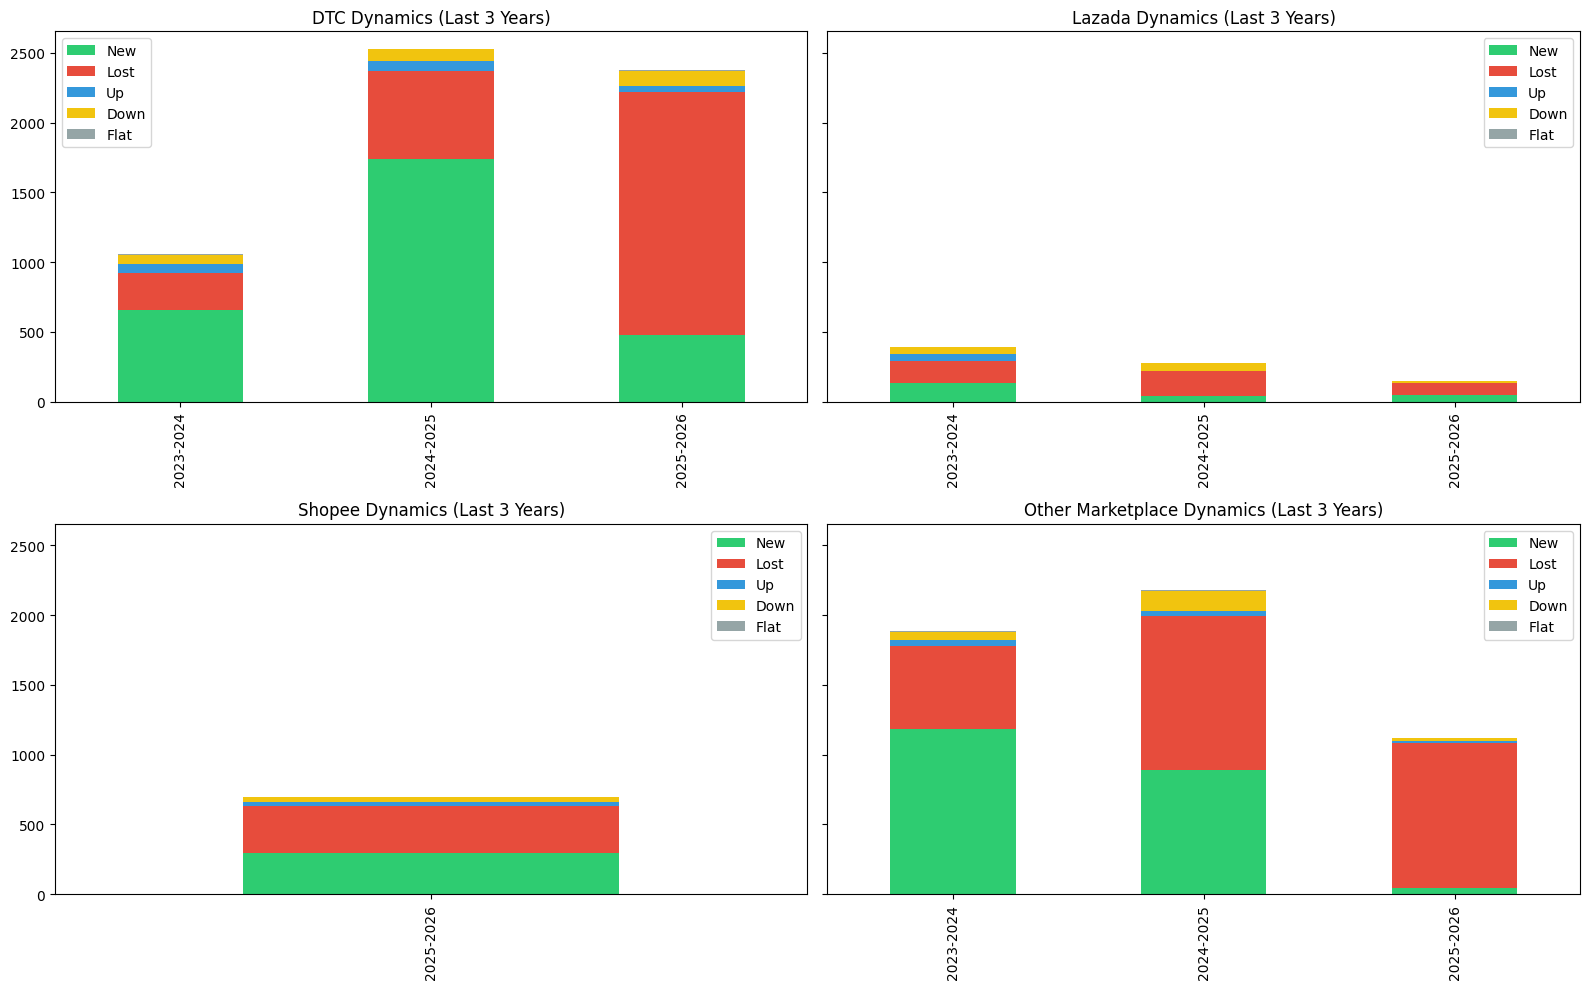

In [18]:
# Up-Down Analysis: Categorizing Revenue YoY

def perform_up_down(df, channel_name):
    """
    Performs a year-over-year 'Up-Down' dynamics analysis for a specific acquisition channel.

    This function tracks customer spending transitions between consecutive years to
    categorize the health of the customer base. It identifies whether customers are
    newly acquired, lost (churned), or increasing/decreasing their annual spend.
    Args:
        df (pd.DataFrame): The 'gold_customer_orders' DataFrame containing at least
            'customer_id', 'year', and 'price_total' columns.
        channel_name (str): The name of the acquisition channel to analyze
            (e.g., 'DTC', 'Lazada', 'Shopee').
    Returns:
        pd.DataFrame: A transition matrix where each column represents a year-pair
        (e.g., '2023-2024') and each row represents a transition category:
            - 'New': Customer had $0 spend in Year 1 and >$0 in Year 2.
            - 'Lost': Customer had >$0 spend in Year 1 and $0 in Year 2.
            - 'Up': Customer spent more in Year 2 than in Year 1.
            - 'Down': Customer spent less in Year 2 than in Year 1 (but >$0).
            - 'Flat': Customer spent exactly the same amount in both years.
    """
    # Filter to include customers from specific acquisition channel
    chan_cust = cp_clean[cp_clean['analysis_channel'] == channel_name]['customer_id']
    df_chan = df[df['customer_id'].isin(chan_cust)].copy()

    # Aggregate spend by customer and year
    yearly_spend = df_chan.groupby(['customer_id', 'year'])['price_total'].sum().unstack(fill_value=0)

    transitions = []
    # Compare spending behavior between consecutive year pairs
    years = sorted(yearly_spend.columns)
    for i in range(len(years)-1):
        y1, y2 = years[i], years[i+1]

        y1_spend = yearly_spend[y1]
        y2_spend = yearly_spend[y2]

        # Define transition logic (Acquisition, Churn, and Expansion)
        conds = [
            (y1_spend == 0) & (y2_spend > 0),       # Newly Acquired
            (y1_spend > 0) & (y2_spend == 0),       # Churned/Lost
            (y1_spend > 0) & (y2_spend > y1_spend), # Increased Spend (Up)
            (y1_spend > 0)
            & (y2_spend > 0)
            & (y2_spend < y1_spend),                 # Decreased Spend (Down)
            (y1_spend > 0) & (y2_spend == y1_spend), # No change (Flat)
        ]
        choices = ['New', 'Lost', 'Up', 'Down', 'Flat']

        # Map conditions and aggregate the counts for the current year-pair
        res = pd.Series(np.select(conds, choices, default='Inactive'), index=y1_spend.index)
        trans_counts = res.value_counts().reindex(choices, fill_value=0)
        trans_counts.name = f"{y1}-{y2}"
        transitions.append(trans_counts)

    return pd.concat(transitions, axis=1)

dtc_updown = perform_up_down(co_successful, 'DTC')
lazada_updown = perform_up_down(co_successful, 'Lazada')
shopee_updown = perform_up_down(co_successful, 'Shopee')
other_updown = perform_up_down(co_successful, 'Other Marketplace')

print("DTC Up-Down Dynamics:")
display(dtc_updown)
print("\nLazada Up-Down Dynamics:")
display(lazada_updown)
print("\nShopee Up-Down Dynamics:")
display(shopee_updown)
print("\nOther Marketplace Up-Down Dynamics:")
display(other_updown)

# Visualize for last 3 years in a 2x2 grid
fig, ax = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
ax = ax.flatten()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f1c40f', '#95a5a6']

dtc_updown.iloc[:, -3:].T.plot(kind='bar', stacked=True, ax=ax[0], color=colors)
ax[0].set_title('DTC Dynamics (Last 3 Years)')

lazada_updown.iloc[:, -3:].T.plot(kind='bar', stacked=True, ax=ax[1], color=colors)
ax[1].set_title('Lazada Dynamics (Last 3 Years)')

shopee_updown.iloc[:, -3:].T.plot(kind='bar', stacked=True, ax=ax[2], color=colors)
ax[2].set_title('Shopee Dynamics (Last 3 Years)')

other_updown.iloc[:, -3:].T.plot(kind='bar', stacked=True, ax=ax[3], color=colors)
ax[3].set_title('Other Marketplace Dynamics (Last 3 Years)')

plt.tight_layout()
plt.show()

### Customer Retention Analysis

**1. DTC (Direct-to-Consumer): High Turnover**
- **What happened:** We gained a lot of new customers in 2024-2025 (1,739 new). However, the very next year (2025-2026), we lost almost the exact same number of people (1,740 lost).
- **What it means:** Very few customers are staying long-term. Last year, only 48 customers upgraded their spending, and only 2 maintained their regular spending. Right now, DTC relies almost entirely on finding new customers just to replace the ones who leave.

**2. Marketplaces: Dropping Numbers**
- **Lazada:** Growth has slowed down significantly over time. It had a great year in 2020-2021 (1,978 new customers), but by 2025-2026, it only brought in 51 new customers while losing 82.
- **Other Marketplaces:** We saw a big jump in 2023-2024 (1,181 new customers), but the drop-off was fast. Last year, we lost 1,044 customers while only gaining 42.
- **Shopee:** In its first year of data (2025-2026), we lost more customers (332) than we gained (297).

**Summary:**
Right now, the business is good at getting new customers to make a purchase, but we struggle to keep them. Across all platforms, when we get a large group of new customers, most of them leave the following year.

To improve the business, we should shift our focus. Instead of spending all our energy on finding new buyers, we need to look at why current buyers are leaving and focus on keeping them happy so they return.

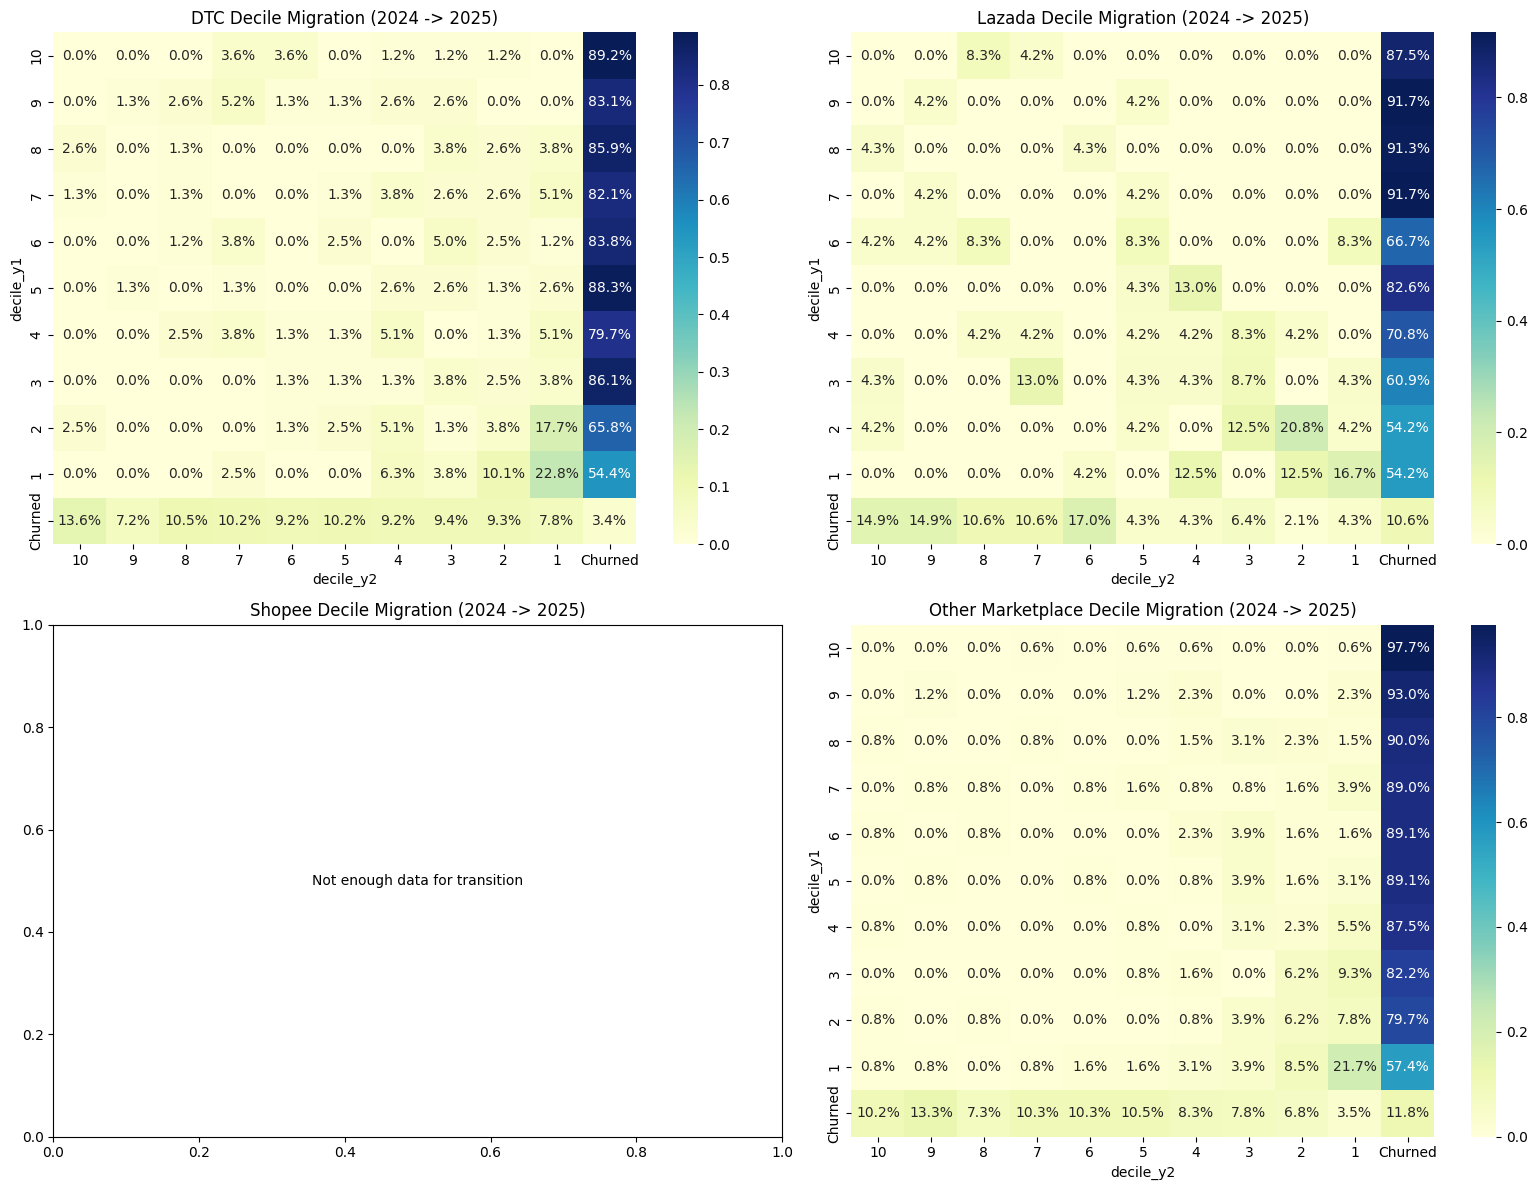

In [19]:
# Decile Migration: Value Stickiness

def decile_migration(df, channel_name, year_start, year_end):
    """
    Analyzes customer value persistence by tracking decile migration between two periods.

    This function categorizes customers into spending deciles for a starting year
    and observes where those same customers end up in a target year (e.g., did
    top-tier 'Decile 1' customers stay at the top, drop to a lower decile, or churn?).
    Args:
        df (pd.DataFrame): The orders DataFrame containing 'customer_id', 'year',
            and 'price_total'.
        channel_name (str): The acquisition channel to filter by.
        year_start (int): The baseline year for decile assignment (e.g., 2023).
        year_end (int): The comparison year to observe migration (e.g., 2024).
    Returns:
        pd.DataFrame or None: A normalized transition matrix (cross-tabulation)
        showing the probability of moving from decile_y1 to decile_y2.
        Returns None if there are fewer than 10 active customers in the starting year.
        Deciles are labeled 1 (Top 10%) to 10 (Bottom 10%), plus 'Churned' for
        customers with zero spend in a given year.
    """
    # Isolate customer orders for the specific acquisition channel
    chan_cust = cp_clean[cp_clean['analysis_channel'] == channel_name]['customer_id']
    df_chan = df[df['customer_id'].isin(chan_cust)].copy()

    # Calculate total annual spend per customer for the start and end years
    y1_spend = df_chan[df_chan['year'] == year_start].groupby('customer_id')['price_total'].sum()
    y2_spend = df_chan[df_chan['year'] == year_end].groupby('customer_id')['price_total'].sum()

    # Combine years and fill missing values with 0 (indicating no spend)
    mig = pd.DataFrame({'y1': y1_spend, 'y2': y2_spend}).fillna(0)

    # Rank Year 1 customers into 10 deciles (D1 = Top 10% spenders)
    active_y1 = mig[mig['y1'] > 0].copy()
    if len(active_y1) < 10: return None

    active_y1['decile_y1'] = pd.qcut(active_y1['y1'], 10, labels=range(10, 0, -1))

    # Assign 'Churned' to customers who were inactive in Year 1
    mig = mig.join(active_y1[['decile_y1']], how='left')
    # Cast to object to avoid Categorical type errors when filling NaNs
    mig['decile_y1'] = mig['decile_y1'].astype(object).fillna('Churned')

    # Repeat decile ranking for Year 2 to track movement
    active_y2 = mig[mig['y2'] > 0].copy()
    if len(active_y2) > 10:
        active_y2['decile_y2'] = pd.qcut(active_y2['y2'], 10, labels=range(10, 0, -1))
        mig = mig.join(active_y2[['decile_y2']], how='left')
        mig['decile_y2'] = mig['decile_y2'].astype(object).fillna('Churned')
    else:
        mig['decile_y2'] = 'Churned'

    # Generate normalized transition matrix (probability of moving between deciles)
    matrix = pd.crosstab(mig['decile_y1'], mig['decile_y2'], normalize='index')

    # Sort matrix logically from Top Spenders (1) to Bottom Spenders (10) to Churned
    order = list(range(10, 0, -1)) + ['Churned']
    # Only keep the indices/columns that actually exist to avoid all-NaN rows/cols
    idx = [x for x in order if x in matrix.index]
    cols = [x for x in order if x in matrix.columns]
    matrix = matrix.loc[idx, cols]

    return matrix

# Calculate migrations for all channels
dtc_mig = decile_migration(co_successful, 'DTC', 2024, 2025)
lazada_mig = decile_migration(co_successful, 'Lazada', 2024, 2025)
shopee_mig = decile_migration(co_successful, 'Shopee', 2024, 2025)
other_mig = decile_migration(co_successful, 'Other Marketplace', 2024, 2025)

migs = {'DTC': dtc_mig, 'Lazada': lazada_mig, 'Shopee': shopee_mig, 'Other Marketplace': other_mig}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, (name, mig) in zip(axes.flatten(), migs.items()):
    if mig is not None:
        sns.heatmap(mig, annot=True, fmt='.1%', cmap='YlGnBu', ax=ax)
        ax.set_title(f"{name} Decile Migration (2024 -> 2025)")
    else:
        ax.text(0.5, 0.5, 'Not enough data for transition', ha='center', va='center')
        ax.set_title(f"{name} Decile Migration (2024 -> 2025)")
plt.tight_layout()
plt.show()

### Customer Movement Analysis: Year 1 to Year 2

**1. The "Wall of Churn" (Almost Everyone Leaves)**
- **What happened:** Look at the dark blue column on the far right of the DTC, Lazada, and Other Marketplace charts. For customers in spending tiers 3 through 10, usually between 80% and 97% of them completely drop off and move to the "Churned" category in year two.
- **What it means:** Customers rarely stick around and grow their spending with us. Instead of moving up to higher spending tiers over time, the vast majority of our shoppers make their purchases in year one and never return.

**2. We Are Losing Our VIP Customers**
- **What happened:** "Decile 1" and "Decile 2" represent our highest-spending, top-tier customers. However, on our own website (DTC), 54.4% of our top spenders and 65.8% of our second-highest spenders leave the following year.
- **What it means:** Our retention problem is not just about losing casual, low-spending buyers. We are struggling to keep our most valuable shoppers loyal to the brand.

**3. Lazada Holds High-Spenders Slightly Better**
- **What happened:** "Other Marketplaces" lose almost everyone, with over 80% of customers leaving in nearly every single spending tier. Lazada has the same 80-90% drop-off for its lower spenders, but it actually performs slightly better at keeping its higher spenders (Deciles 1 through 4) compared to the other channels.
- **What it means:** While churn is a massive issue everywhere, Lazada's high-value customers are slightly more resilient and likely to return than the high-value customers on our own website or other marketplaces.

**4. Shopee is Too New**
- **What happened:** The Shopee chart is empty with a "Not enough data for transition" message.
- **What it means:** Because Shopee was likely just launched or only has one year of clean data, we cannot yet see how those customers behave year-over-year.

**Summary:** The data clearly shows that we do not have a customer loyalty pipeline. Across almost all channels and spending levels, customers hit a "wall" and leave the brand in their second year. Most concerning is that we lose more than half of our absolute best, highest-spending customers (Decile 1) year over year. Fixing the post-purchase experience for these top-tier VIPs should be our most urgent priority.

## 3 - Vitality Analysis (BG/NBD)

Channel Vitality (P_Alive):


,mean,median,std
analysis_channel,,,
DTC,0.741,1.0,0.392
Lazada,0.619,1.0,0.453
Other Marketplace,0.805,1.0,0.357
Shopee,0.880,1.0,0.257


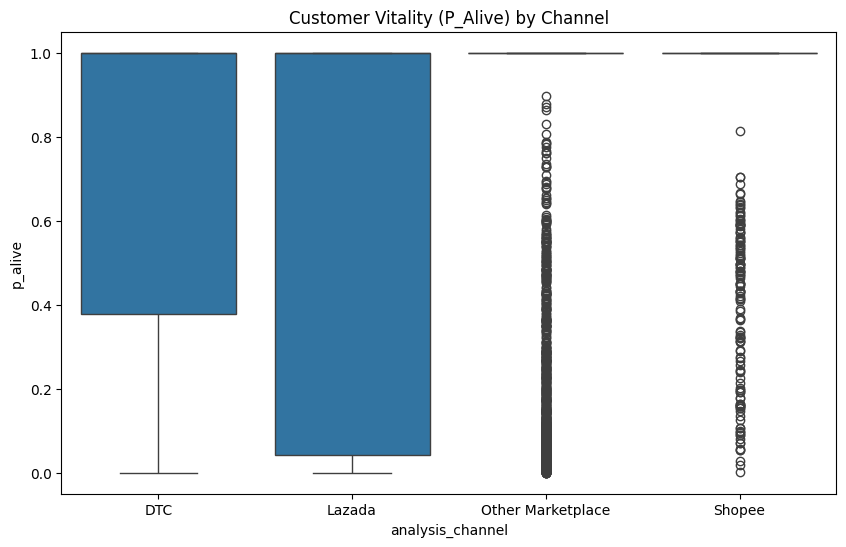

In [20]:
# !pip install lifetimes
try:
    from lifetimes import BetaGeoFitter
    
    # BG/NBD Model expects Frequency (repeat orders), Recency (time between first and last), 
    # and T (tenure since first order)
    bgf = BetaGeoFitter(penalizer_coef=0.0)
    bgf.fit(analysis_df['AOF'], analysis_df['recency_days'], analysis_df['tenure_days'])
    
    # Calculate Probability of Being Alive for each customer
    analysis_df['p_alive'] = bgf.conditional_probability_alive(analysis_df['AOF'], 
                                                               analysis_df['recency_days'], 
                                                               analysis_df['tenure_days'])
    
    # Group by channel
    vitality = analysis_df.groupby('analysis_channel')['p_alive'].agg(['mean', 'median', 'std']).round(3)
    print("Channel Vitality (P_Alive):")
    display(vitality)
    
    # Visualize
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='analysis_channel', y='p_alive', data=analysis_df)
    plt.title('Customer Vitality (P_Alive) by Channel')
    plt.show()
    
except ImportError:
    print("Lifetimes library not installed. Please run !pip install lifetimes to execute Vitality Analysis.")

### Customer Activity (Vitality) Analysis

> Note: The "activity score" represents the probability that a customer is still active and likely to buy again, with 1.0 being fully active and 0.0 being completely churned.

**1. At First Glance, Most Customers Look Active**
- **What happened:** If you look at the median (the middle number) in the table, it is exactly 1.0 for every single channel.
- **What it means:** For more than half of the customers across all platforms, the system predicts they are still fully active. We have a solid core of engaged shoppers everywhere.

**2. Lazada Has the Largest Fading Customer Base**
- **What happened:** Despite having a high median, Lazada has the lowest overall average score (0.619) and the widest spread of data (shown by the massive blue box stretching all the way to the bottom of the chart).
- **What it means:** Lazada's customer base is highly divided. While they have active users, a massive portion of their customers have activity scores near zero, pulling the channel's overall average way down.

**3. Shopee Appears the "Healthiest" (But Context Matters)**
- **What happened:** Shopee has the highest average activity score (0.880) and the data is tightly packed at the top of the chart (represented by the flat line at 1.0).
- **What it means:** Shopee currently holds our most "alive" customer base. However, keeping our previous analyses in mind, this is likely because Shopee is our newest channel. These customers simply haven't been around long enough to churn yet.

**4. Our Website (DTC) is a Mixed Bag**
- **What happened:** DTC sits in the middle with an average score of 0.741. However, looking at the chart, the bottom 25% of our website customers have scores that drop below 0.4.
- **What it means:** While our website has a strong core of active shoppers, a noticeable and significant chunk of the user base is rapidly fading away.

**Summary:** The median numbers are hiding a bigger problem. While the top half of our customers are highly active across the board, the bottom half tells a different story. Lazada is currently carrying a huge amount of "dead weight"—customers who are no longer engaging. Shopee looks incredibly healthy right now, but we must be careful, as this is likely just the "honeymoon phase" of a new channel before the inevitable churn hits.

## 4 - Projected Value (Gamma-Gamma)

Channel Value Projection (12-Month Residual CLV):


,Mean Predicted CLV (12m),Median Predicted CLV (12m),Total Predicted Revenue (12m)
analysis_channel,,,
Shopee,86.17,58.43,59542.62
DTC,28.52,10.89,159045.68
Lazada,23.64,4.38,86469.22
Other Marketplace,20.05,12.05,61581.63


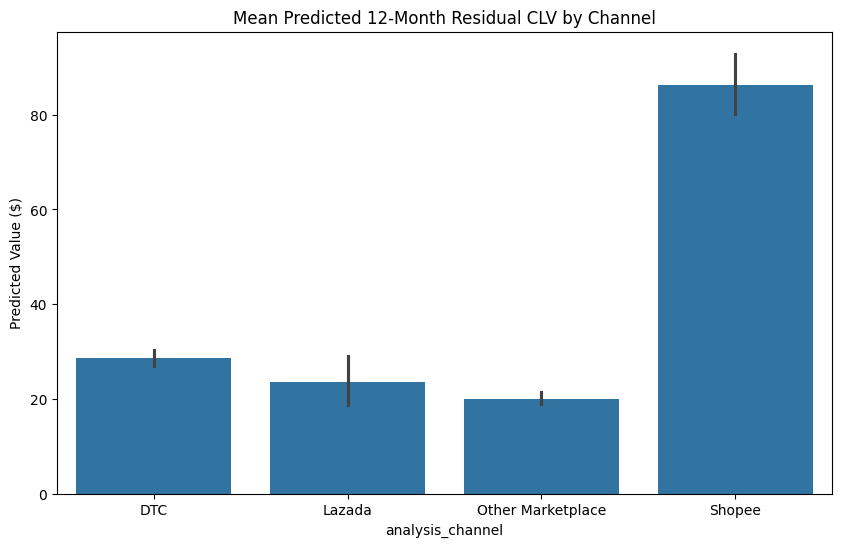

In [21]:
try:
    from lifetimes import GammaGammaFitter

    # Gamma-Gamma requires Frequency > 0 and AOV > 0
    gg_df = analysis_df[(analysis_df["AOF"] > 0) & (analysis_df["AOV"] > 0)].copy()

    ggf = GammaGammaFitter(penalizer_coef=0.0)
    ggf.fit(gg_df['AOF'], gg_df['AOV'])

    # Predict Residual CLV for all customers (including frequency=0)
    # We use the BG/NBD and Gamma-Gamma models together
    analysis_df["predicted_clv_12m"] = ggf.customer_lifetime_value(
        bgf,
        analysis_df["AOF"],
        analysis_df["recency_days"],
        analysis_df["tenure_days"],
        analysis_df["AOV"],
        time=12,  # 12 months future projection
        discount_rate=0.01,  # Monthly discount rate
    )

    # Rank channels by Predicted Future Value
    clv_summary = analysis_df.groupby('analysis_channel')['predicted_clv_12m'].agg(['mean', 'median', 'sum']).round(2)
    clv_summary.columns = ['Mean Predicted CLV (12m)', 'Median Predicted CLV (12m)', 'Total Predicted Revenue (12m)']
    print("Channel Value Projection (12-Month Residual CLV):")
    display(clv_summary.sort_values('Mean Predicted CLV (12m)', ascending=False))

    # Visualize
    plt.figure(figsize=(10, 6))
    sns.barplot(x='analysis_channel', y='predicted_clv_12m', data=analysis_df, estimator=np.mean)
    plt.title('Mean Predicted 12-Month Residual CLV by Channel')
    plt.ylabel('Predicted Value ($)')
    plt.show()

except ImportError:
    print("Lifetimes library not installed. Please run !pip install lifetimes to execute Value Projection.")

### Future Customer Value (12-Month Prediction) Analysis

> Note: This data predicts how much money our current customers will spend with us over the next year.

**1. Shopee Customers Predict the Highest Individual Spend**
- **What happened:** Looking at the chart, Shopee completely towers over the other channels. The model predicts the average Shopee customer will spend $86.17 over the next year, which is triple the predicted value of a DTC customer.
- **What it means:** On an individual level, Shopee customers look incredibly valuable. However, keeping our previous findings in mind, Shopee is a brand-new channel. These predictions might be artificially high simply because these customers haven't been around long enough to hit the "churn wall" yet.

**2. Our Website (DTC) is the Total Revenue Engine**
- **What happened:** Even though individual DTC customers are predicted to spend less (an average of $28.52), the "Total Predicted Revenue" column shows DTC will bring in $159,045.68 over the next year—nearly double the next closest channel.
- **What it means:** Our website strategy relies entirely on sheer volume. We aren't making money from highly loyal VIPs; we are making money by pushing a massive number of lower-spending customers through the checkout.

**3. Lazada is Mostly "Dead Weight"**
- **What happened:** Lazada has a decent "mean" (average) predicted spend of $23.64. However, if you look at the "median" (the exact middle customer), the predicted spend plummets to a tiny $4.38.
- **What it means:** This confirms our earlier "fading customer base" theory. More than half of our Lazada customers are predicted to spend little to nothing with us next year. A very small handful of big spenders is pulling the average up, but the vast majority of the Lazada user base is effectively dead.

**Summary:** When we look at the next 12 months, our website (DTC) will continue to carry the business purely because of its massive size, even though individual customers don't spend much. Shopee shows exciting potential for high-spending individuals, but we need to see if that holds true as the channel ages. Finally, the data confirms that most of our historical Lazada customers have permanently stopped buying.

## Conclusion

### 1. Does the acquisition channel impact customer loyalty?
**Answer: Yes, significantly.** 
* **Channel matters more than location:** The data proves that *how* a customer finds us (the platform) is the primary driver of whether they return. It completely overrides geographic factors, meaning a customer's channel matters much more than whether they live in Singapore or Malaysia.

* **The Winner (Lazada):** Lazada intrinsically drives the best 90-day retention. Customers acquired here are much more likely to return than those buying directly from our website (DTC).

* **The Loser (Shopee):** Customers acquired through Shopee are the least loyal, dropping off significantly faster than our website baseline.

### 2. Which channel produces the most valuable customers (Highest LTV)?
**Answer: It depends on whether we are looking at individual spenders or total revenue.**

* **Highest Potential Individual Spend (Shopee):** On an individual level, Shopee customers are predicted to spend the most over the next 12 months (an average of $86.17 per user). **Caution:** Because Shopee is a brand-new channel, these high numbers are risky and very likely to drop once normal churn sets in.

* **Biggest Overall Revenue Engine (DTC):** Our website generates the highest total lifetime value by far, projected to bring in $159,045 over the next 12 months. Even though individual website customers spend very little (averaging $28.52), the massive volume of users pushes total revenue to the top.

* **The Fallen Champion (Lazada):** Historically, Lazada acquired our absolute best customers (highest initial spend and best retention). However, that growth has stopped. The user base has gone inactive, crashing the median predicted future spend down to just $4.38 per person.